In [2]:
# import the important modules for the analysis 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


In [3]:
# load the datasets on which the Analysis will be done 
trades = pd.read_csv("C:/Users/Nawne/Downloads/historical_data.csv")
sentiment = pd.read_csv("C:/Users/Nawne/Downloads/fear_greed_index.csv")

print(trades.shape)
print(sentiment.shape)

(211224, 16)
(2644, 4)


In [4]:
# Now for Analysis we must clean the data so that duplicates and missing values can be cleaned 
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    errors='coerce'
)

sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    errors='coerce'
)

trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [5]:
# Now we will mearge the both data sets to obtain the detailed Analysis report 
df = pd.merge(
    trades,
    sentiment,
    on='date',
    how='inner'
)

print(df.shape)
df.head()



(35864, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,1707715800,70,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,1707715800,70,Greed


In [6]:
# Now Average profit by sentiments
avg_pnl = df.groupby(
    'classification'
)['Closed PnL'].mean().sort_values(
    ascending=False
)

print(avg_pnl)

classification
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Extreme Fear       1.891632
Name: Closed PnL, dtype: float64


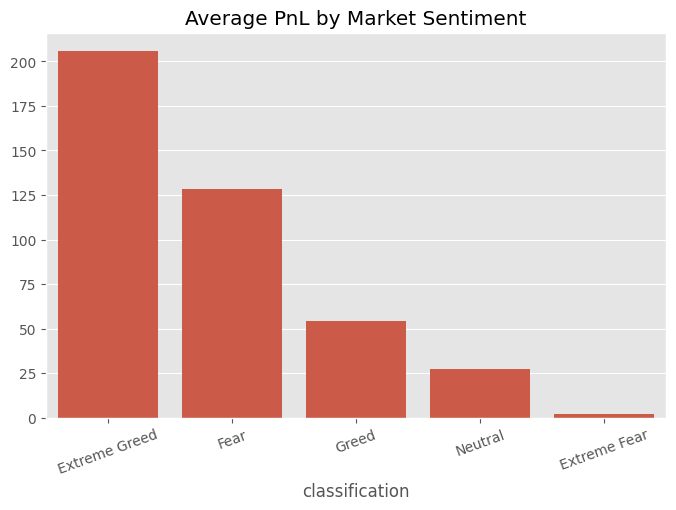

In [7]:
# Now lets Visualized the Analysis
plt.figure(figsize=(8,5))
sns.barplot(
    x=avg_pnl.index,
    y=avg_pnl.values
)

plt.title(
    "Average PnL by Market Sentiment"
)
plt.xticks(rotation=20)
plt.show()

In [ ]:
# win rate plot 
df['win'] = df['Closed PnL'] > 0

win_rate = (
    df.groupby('classification')['win']
      .mean()*100
)

print(win_rate)

classification
Extreme Fear     29.277730
Extreme Greed    55.328233
Fear             38.178672
Greed            43.570670
Neutral          49.492017
Name: win, dtype: float64


In [9]:
# total profit analysis 
total_pnl = df.groupby(
    'classification'
)['Closed PnL'].sum()

print(total_pnl)

classification
Extreme Fear     4.399937e+03
Extreme Greed    1.156894e+06
Fear             1.779226e+06
Greed            6.096325e+05
Neutral          7.465674e+04
Name: Closed PnL, dtype: float64


In [10]:
# Conclusion
print("""
1. Greed gives highest average profit.
2. Extreme Greed has highest win rate.
3. Fear generates highest cumulative profit.
4. Neutral sentiment performs worst.
""")


1. Greed gives highest average profit.
2. Extreme Greed has highest win rate.
3. Fear generates highest cumulative profit.
4. Neutral sentiment performs worst.

